# Telco Customer Churn: From Historical Patterns to Customer Risk

## Project introduction

Customer churn reduces recurring revenue and can signal problems in the customer experience. This notebook uses the IBM Telco Customer Churn dataset to describe historical churn patterns, compare customer segments, evaluate classification models, and prepare a customer-level scoring file for Power BI.

The intended audience is a business or analytics reader who wants to understand both the findings and how they were produced. Each section states its purpose, explains how to read its tables or charts, and flags the limits of the evidence. The analysis is exploratory and educational: it does not establish why customers leave, prove that a retention action will work, or replace validation on current company data.

## Questions this notebook answers

1. How many customers churned in this historical dataset, and what is the observed churn rate?
2. Which contract, tenure, service, and billing groups show different observed churn rates?
3. Do the selected models identify churners on a held-out test set, and what trade-offs do they make?
4. How do classification metrics and workload change when the probability threshold changes?
5. How can customer scores be exported with actual outcomes, probabilities, flags, and operational tiers clearly distinguished?

## Analytical path

**Business context → data checks → descriptive churn analysis → feature design → held-out model evaluation → threshold and calibration checks → full-customer scoring → Power BI outputs → recommendations and limitations**

## Read these measures carefully

- **Actual churn rate** is the share of records whose historical `Churn` outcome is Yes.
- **Churn probability** is a model score for an individual customer. An average of scores is not automatically the actual churn rate, especially before calibration is assessed.
- **Predicted churn rate at a threshold** is the share of customers whose score meets that threshold.
- **Risk tier** is an operational grouping used here for reporting; its boundaries are not proven to be optimal intervention cut-offs.

## Reproducibility and scope

The notebook uses a fixed random seed and a stratified 80/20 train/test split. Learned preprocessing and SMOTE are fitted using training data only; the held-out test set keeps the original churn mix. The source CSV path is set in Section 1 and may need to be changed for your environment. The final scoring table covers the full historical customer file, including records used during training, so it is for segmentation and dashboarding rather than independent model evaluation.

Run the notebook from top to bottom. Existing saved outputs are retained where they still match the original analysis; newly added diagnostic cells will show their results after execution.


## 1. Setup & Imports

This section loads the libraries used for data handling, charts, preprocessing, modelling, evaluation, and resampling. `RANDOM_STATE` makes randomized steps repeatable. `DATA_PATH` points to the source CSV and `OUTPUT_PATH` names the Power BI workbook created near the end; update these paths when running outside the original Colab environment.

The printed confirmation means the imports completed. It does not yet confirm that the dataset path is valid; that is checked in Section 2.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, precision_score, recall_score, f1_score,
    accuracy_score, brier_score_loss, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

RANDOM_STATE = 42
DATA_PATH = '/content/WA_Fn-UseC_-Telco-Customer-Churn (1).csv'
OUTPUT_PATH = 'churn_scored_data_v2.xlsx'

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
pd.set_option('display.max_columns', 50)

print('Libraries loaded.')

Libraries loaded.


## 2. Load the Dataset

The source file is read once into `df`. The displayed first rows are a quick visual check of column names, values, and record shape. Confirm that `Churn` is the target and that `customerID` identifies customers before proceeding. A missing-file error means `DATA_PATH` must be updated; do not silently substitute a different dataset.


In [2]:
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f'Dataset not found at {DATA_PATH}. Update DATA_PATH in Section 1 to the location of the CSV.'
    )

df = pd.read_csv(DATA_PATH)

print(f'Loaded {len(df):,} rows × {df.shape[1]} columns.')
df.head()

Loaded 7,043 rows × 21 columns.


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 3. Data Quality & Target Inspection

The first output reports data types and non-null counts; the missing-value summary shows where cleaning may be needed. Duplicate counts check whether customer IDs or complete records repeat. These checks describe the source before transformation.

`TotalCharges` is stored as text in the source, so the next output checks which values fail numeric conversion. The blank values are only filled with zero after confirming that they belong to customers with zero tenure, for whom no accumulated charge is recorded. The quality summary then records the retained row count and target balance. A churn proportion is the share of records in each class, not a model score.


In [3]:
print('--- Data types and non-null counts ---')
df.info()

print('\n--- Missing values before type conversion ---')
print(df.isnull().sum().sort_values(ascending=False))

print('\n--- Duplicate checks ---')
print('Duplicate customerID rows:', df['customerID'].duplicated().sum())
print('Duplicate full rows:', df.duplicated().sum())

--- Data types and non-null counts ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  Pap

In [4]:
# TotalCharges is stored as text in the raw file. Convert it to numeric so that
# blanks become explicit missing values rather than silently remaining strings.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

missing_totalcharges = df['TotalCharges'].isna().sum()
missing_tenure_zero = (df.loc[df['TotalCharges'].isna(), 'tenure'] == 0).sum()

print('Missing TotalCharges after coercion:', missing_totalcharges)
print('Of these, tenure == 0:', missing_tenure_zero)

print('\nRows requiring the TotalCharges handling rule:')
display(df.loc[df['TotalCharges'].isna(), ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']].head(15))

Missing TotalCharges after coercion: 11
Of these, tenure == 0: 11

Rows requiring the TotalCharges handling rule:


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


In [5]:
# These missing values correspond to new customers with tenure == 0 and therefore
# no accumulated bill yet. Filling them with 0 avoids fabricating historical spend.
df['TotalCharges'] = df['TotalCharges'].fillna(0)

df['ChurnFlag'] = (df['Churn'] == 'Yes').astype(int)

quality_summary = pd.DataFrame({
    'Check': [
        'Rows loaded',
        'Columns loaded',
        'Duplicate customerID rows',
        'Duplicate full rows',
        'Blank TotalCharges handled',
        'Rows remaining after cleaning'
    ],
    'Value': [
        len(df),
        df.shape[1],
        df['customerID'].duplicated().sum(),
        df.duplicated().sum(),
        missing_totalcharges,
        len(df)
    ]
})

display(quality_summary)
print('\nTarget distribution:')
display(df['Churn'].value_counts(normalize=True).rename('Proportion').round(4))

,Check,Value
0,Rows loaded,7043
1,Columns loaded,22
2,Duplicate customerID rows,0
3,Duplicate full rows,0
4,Blank TotalCharges handled,11
5,Rows remaining after cleaning,7043



Target distribution:


,Proportion
Churn,
No,0.7346
Yes,0.2654


## 4. Establish the Churn Baseline

This section answers the descriptive question: what share of customers actually churned in the historical file? The printed count and percentage form a baseline for the segment analysis that follows.

In Figure 1, bar height is the number of customers in each outcome class. Because the classes have different sizes, use the printed rate for percentage comparisons; the chart itself shows counts. This baseline is descriptive and should not be read as a prediction of future churn.


Total customers: 7,043
Customers churned: 1,869
Actual churn rate: 26.5%


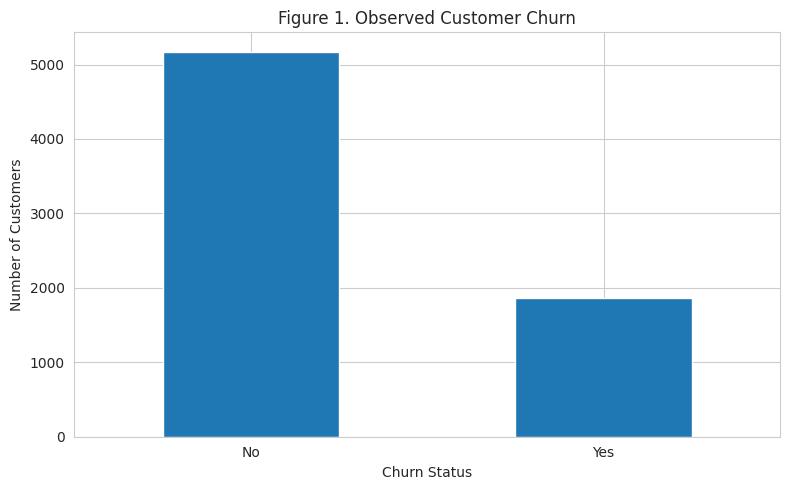

In [6]:
overall_churn_rate = df['ChurnFlag'].mean()
churned_customers = int(df['ChurnFlag'].sum())
total_customers = len(df)

print(f'Total customers: {total_customers:,}')
print(f'Customers churned: {churned_customers:,}')
print(f'Actual churn rate: {overall_churn_rate:.1%}')

fig, ax = plt.subplots()
counts = df['Churn'].value_counts().reindex(['No', 'Yes'])
counts.plot(kind='bar', ax=ax)
ax.set_title('Figure 1. Observed Customer Churn')
ax.set_xlabel('Churn Status')
ax.set_ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 5. Exploratory Analysis — Which Segments Show Different Churn Behaviour?

This section compares observed churn rates across a focused set of business-relevant groups. Each summary table reports the group size, churn count, and within-group churn rate. Read rates together with customer counts: a high rate in a very small group may be less stable than a similar rate in a large group.

Figure 2 compares contract groups with the overall churn rate shown as a dashed reference. Figure 3 shows tenure by outcome; the tenure-group table gives churn rates for fixed month ranges. Figure 4 brings selected service and billing comparisons together. Figure 5 compares monthly-charge distributions by outcome, while Figure 6 shows correlations among selected numeric variables. A correlation indicates association, not cause; the strong relationship between tenure and total charges also means their separate model effects need care.


,Contract,Customers,Churned,ChurnRate
0,Month-to-month,3875,1655,0.4271
1,One year,1473,166,0.1127
2,Two year,1695,48,0.0283


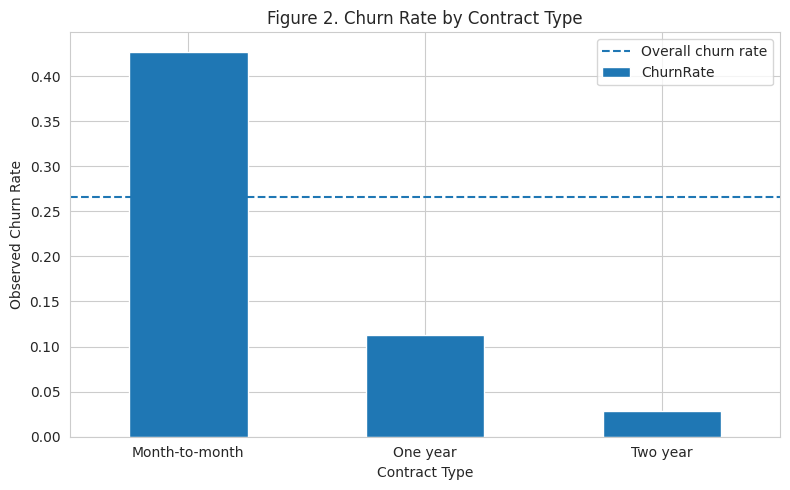

In [7]:
def churn_rate_by(column):
    result = (
        df.groupby(column, observed=True)['ChurnFlag']
          .agg(Customers='count', Churned='sum', ChurnRate='mean')
          .reset_index()
          .sort_values('ChurnRate', ascending=False)
    )
    result['ChurnRate'] = result['ChurnRate'].round(4)
    return result

contract_summary = churn_rate_by('Contract')
display(contract_summary)

fig, ax = plt.subplots()
contract_summary.plot(x='Contract', y='ChurnRate', kind='bar', legend=False, ax=ax)
ax.axhline(overall_churn_rate, linestyle='--', label='Overall churn rate')
ax.set_title('Figure 2. Churn Rate by Contract Type')
ax.set_xlabel('Contract Type')
ax.set_ylabel('Observed Churn Rate')
ax.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

,TenureGroup,Customers,Churned,ChurnRate
0,0-6mo,1481,784,0.5294
1,7-12mo,705,253,0.3589
2,13-24mo,1024,294,0.2871
3,25-48mo,1594,325,0.2039
4,49-72mo,2239,213,0.0951


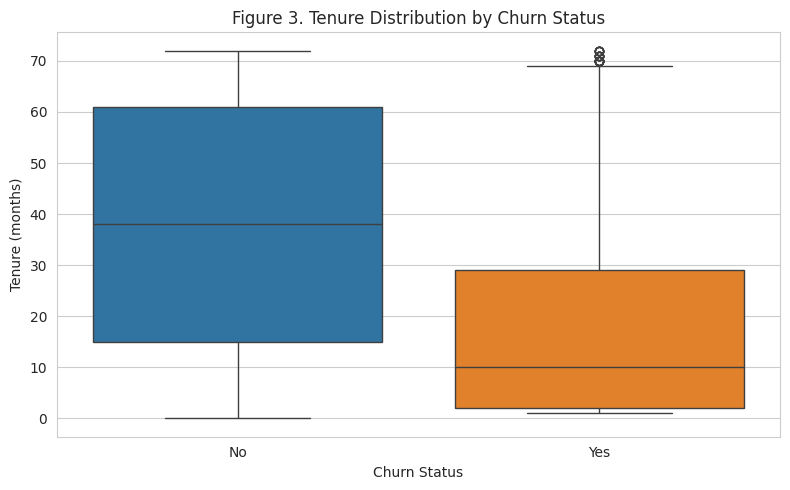

In [8]:
# Tenure is analysed both numerically and through business-friendly groups.
df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[-1, 6, 12, 24, 48, 72],
    labels=['0-6mo', '7-12mo', '13-24mo', '25-48mo', '49-72mo']
)

tenure_summary = churn_rate_by('TenureGroup')
display(tenure_summary)

fig, ax = plt.subplots()
sns.boxplot(data=df, x='Churn', y='tenure', hue='Churn', legend=False, ax=ax)
ax.set_title('Figure 3. Tenure Distribution by Churn Status')
ax.set_xlabel('Churn Status')
ax.set_ylabel('Tenure (months)')
plt.tight_layout()
plt.show()

--- InternetService ---


,InternetService,Customers,Churned,ChurnRate
1,Fiber optic,3096,1297,0.4189
0,DSL,2421,459,0.1896
2,No,1526,113,0.0740


--- TechSupport ---


,TechSupport,Customers,Churned,ChurnRate
0,No,3473,1446,0.4164
2,Yes,2044,310,0.1517
1,No internet service,1526,113,0.0740


--- PaymentMethod ---


,PaymentMethod,Customers,Churned,ChurnRate
2,Electronic check,2365,1071,0.4529
3,Mailed check,1612,308,0.1911
0,Bank transfer (automatic),1544,258,0.1671
1,Credit card (automatic),1522,232,0.1524


--- PaperlessBilling ---


,PaperlessBilling,Customers,Churned,ChurnRate
1,Yes,4171,1400,0.3357
0,No,2872,469,0.1633


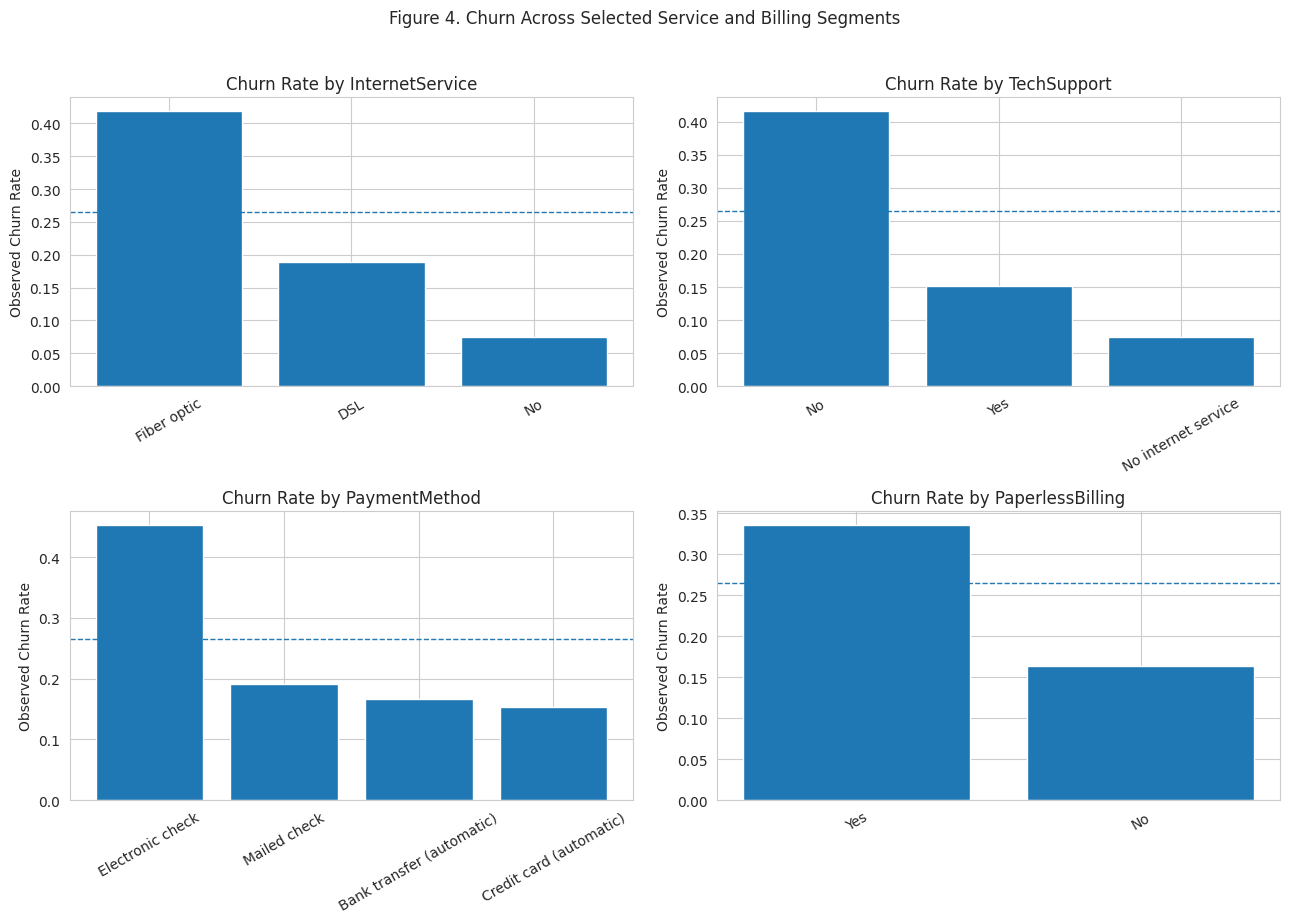

In [9]:
# Service and billing variables are reviewed together because they provide
# actionable customer-segment views for the eventual Power BI dashboard.
segment_features = ['InternetService', 'TechSupport', 'PaymentMethod', 'PaperlessBilling']
segment_tables = {}

for col in segment_features:
    segment_tables[col] = churn_rate_by(col)
    print(f'--- {col} ---')
    display(segment_tables[col])

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, col in zip(axes.flat, segment_features):
    rates = segment_tables[col].sort_values('ChurnRate', ascending=False)
    ax.bar(rates[col].astype(str), rates['ChurnRate'])
    ax.axhline(overall_churn_rate, linestyle='--', linewidth=1)
    ax.set_title(f'Churn Rate by {col}')
    ax.set_ylabel('Observed Churn Rate')
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Figure 4. Churn Across Selected Service and Billing Segments', y=1.02)
plt.tight_layout()
plt.show()

### Focused segment interaction: contract × internet service

Contract and internet service are both associated with churn in the one-variable summaries. This compact cross-tab checks whether their combination provides a useful dashboard segment. It reports customers, observed churn rate, and churn count for each combination. Check group size before highlighting a high rate; this is exploratory and does not show that either attribute causes churn.


,Contract,InternetService,Customers,ChurnedCustomers,ActualChurnRate
1,Month-to-month,Fiber optic,2128,1162,0.5461
0,Month-to-month,DSL,1223,394,0.3222
4,One year,Fiber optic,539,104,0.1929
2,Month-to-month,No,524,99,0.1889
3,One year,DSL,570,53,0.0930
7,Two year,Fiber optic,429,31,0.0723
5,One year,No,364,9,0.0247
6,Two year,DSL,628,12,0.0191
8,Two year,No,638,5,0.0078


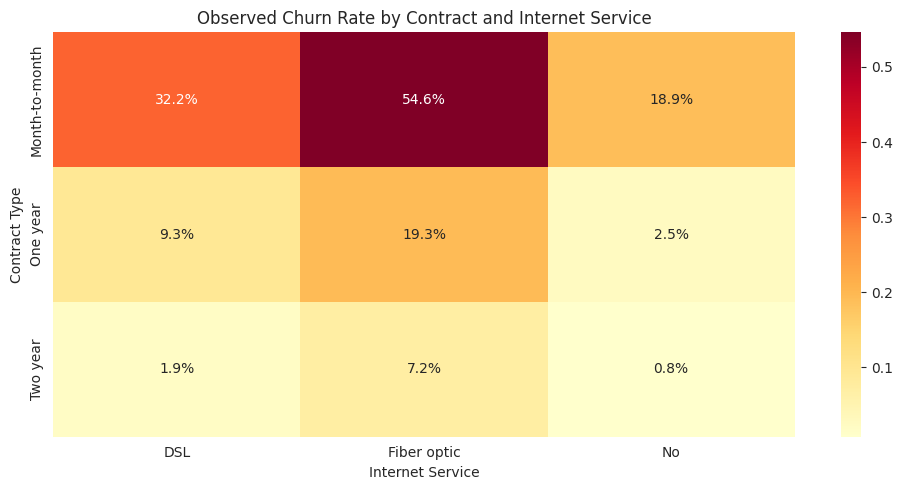

In [10]:
contract_internet_summary = (
    df.groupby(['Contract', 'InternetService'], observed=True)
      .agg(
          Customers=('customerID', 'count'),
          ChurnedCustomers=('ChurnFlag', 'sum'),
          ActualChurnRate=('ChurnFlag', 'mean')
      )
      .reset_index()
      .sort_values(['ActualChurnRate', 'Customers'], ascending=[False, False])
)
contract_internet_summary['ActualChurnRate'] = contract_internet_summary['ActualChurnRate'].round(4)
display(contract_internet_summary)

fig, ax = plt.subplots(figsize=(10, 5))
interaction_pivot = contract_internet_summary.pivot(
    index='Contract', columns='InternetService', values='ActualChurnRate'
)
sns.heatmap(interaction_pivot, annot=True, fmt='.1%', cmap='YlOrRd', ax=ax)
ax.set_title('Observed Churn Rate by Contract and Internet Service')
ax.set_xlabel('Internet Service')
ax.set_ylabel('Contract Type')
plt.tight_layout()
plt.show()


**How to read the interaction output:** the table gives the group size and observed rate for each contract/service pair; the heatmap makes rate differences easier to scan. Use the table's counts to qualify the colors. These historical combinations are candidate segments for further investigation, not proof of causal risk factors. Figure numbers below are retained from the source notebook; this added chart is an additional segment view.


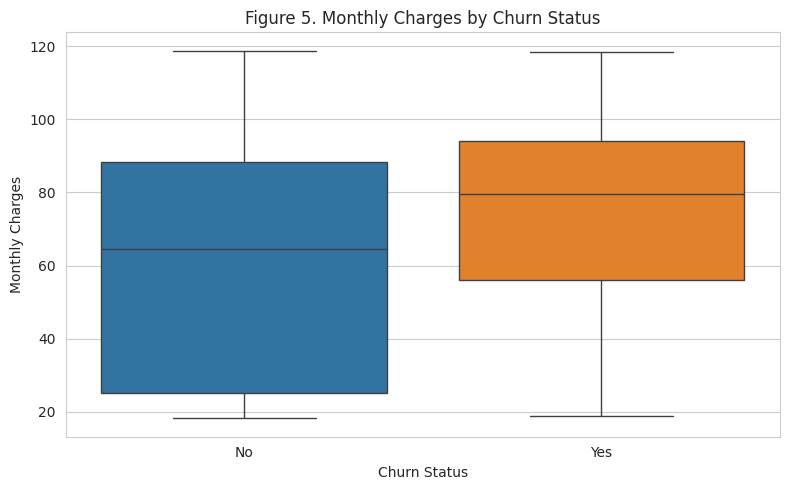

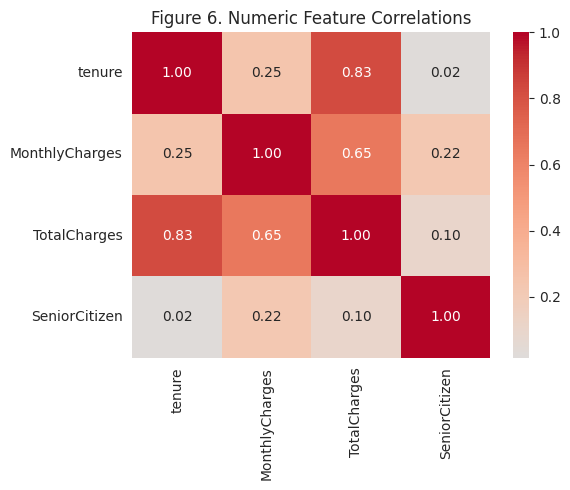

In [11]:
# Numeric behaviour: compare monthly charges between customers who churned and retained customers.
fig, ax = plt.subplots()
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', hue='Churn', legend=False, ax=ax)
ax.set_title('Figure 5. Monthly Charges by Churn Status')
ax.set_xlabel('Churn Status')
ax.set_ylabel('Monthly Charges')
plt.tight_layout()
plt.show()

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
correlation_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Figure 6. Numeric Feature Correlations')
plt.tight_layout()
plt.show()

### EDA interpretation

The EDA should now answer a limited set of questions:

- **Scale:** the overall churn rate establishes the baseline.
- **Customer relationship:** contract type and tenure reveal major differences between churn groups.
- **Service and billing:** selected service/payment variables identify segments that warrant further investigation.
- **Numeric behaviour:** tenure and monthly charges provide additional predictive information.
- **Redundancy:** the correlation matrix flags relationships such as the strong association between tenure and TotalCharges, which matters when interpreting a linear model.

These findings motivate the feature-engineering and modelling choices below; the notebook does not treat every available variable as equally important.

## 6. Feature Engineering & Modelling Specification

The added fields express customer characteristics in business-friendly or potentially useful forms: `TenureGroup` captures broad tenure bands, `NumAddonServices` counts selected add-on services, and `AvgMonthlySpend` divides accumulated charges by tenure (using current monthly charges at zero tenure). The preview checks that these values were created as intended.

The engineered fields are candidate representations, not improvements by definition. Section 11.2 compares the Logistic Regression workflow with and without `AvgMonthlySpend` on the same held-out split. All feature transformations are fitted using training data only. The comparison is separate from the model selected for full-customer scoring.


In [12]:
addon_cols = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

df['NumAddonServices'] = (df[addon_cols] == 'Yes').sum(axis=1)
df['AvgMonthlySpend'] = np.where(
    df['tenure'] > 0,
    df['TotalCharges'] / df['tenure'],
    df['MonthlyCharges']
)

display(df[['tenure', 'TenureGroup', 'NumAddonServices', 'AvgMonthlySpend', 'ChurnFlag']].head())

,tenure,TenureGroup,NumAddonServices,AvgMonthlySpend,ChurnFlag
0,1,0-6mo,1,29.850000,0
1,34,25-48mo,2,55.573529,0
2,2,0-6mo,2,54.075000,1
3,45,25-48mo,3,40.905556,0
4,2,0-6mo,0,75.825000,1


In [13]:
numeric_features = [
    'tenure', 'MonthlyCharges', 'TotalCharges',
    'NumAddonServices', 'AvgMonthlySpend'
]

categorical_features = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod', 'TenureGroup'
]

X = df[numeric_features + categorical_features].copy()
y = df['ChurnFlag'].copy()

print('Feature matrix:', X.shape)
print('Target mean:', round(y.mean(), 4))

Feature matrix: (7043, 22)
Target mean: 0.2654


## 7. Train/Test Split

The data is separated before fitting a scaler, encoder, resampler, or model. Stratification keeps the churn proportion similar in the train and test partitions. The printed row counts should add to the full dataset, and the two churn rates should be close.

The test set remains held back for model comparison and diagnostics. Do not use full-customer scoring results later in the notebook as if they were test-set performance.


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f'Train rows: {len(X_train):,}')
print(f'Test rows:  {len(X_test):,}')
print(f'Train churn rate: {y_train.mean():.1%}')
print(f'Test churn rate:  {y_test.mean():.1%}')

Train rows: 5,634
Test rows:  1,409
Train churn rate: 26.5%
Test churn rate:  26.5%


## 8. Preprocessing & Class Imbalance

Numeric values are standardised and categorical values are one-hot encoded. `fit_transform` learns preprocessing rules from the training rows; the test set is only transformed with those learned rules. The output shapes show how many rows and encoded features the model receives.

SMOTE increases the minority class in the training set only. The before/after counts should show a balanced resampled training target, while the test set remains unchanged. Because this implementation applies ordinary SMOTE after one-hot encoding, synthetic examples can contain fractional category indicators. Treat this as a modelling limitation; `SMOTENC` or a pipeline that handles categorical features directly is a stronger follow-up.


In [15]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print('Processed train shape:', X_train_processed.shape)
print('Processed test shape:', X_test_processed.shape)

Processed train shape: (5634, 53)
Processed test shape: (1409, 53)


In [16]:
print('Before SMOTE:', y_train.value_counts().to_dict())

smote = SMOTE(random_state=RANDOM_STATE)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_processed, y_train)

print('After SMOTE:', pd.Series(y_train_resampled).value_counts().to_dict())

Before SMOTE: {0: 4139, 1: 1495}
After SMOTE: {0: 4139, 1: 4139}


## 9. Model Development

The three classifiers offer a simple interpretable baseline and two tree-based alternatives. They use the same training split, transformed features, and resampled training rows so that the held-out comparison is reasonably aligned. Model choice is guided by the project objective rather than accuracy alone: churn recall is the primary metric because false negatives represent churners the model failed to flag.


In [17]:
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_resampled, y_train_resampled)

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train_resampled, y_train_resampled)

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
xgb.fit(X_train_resampled, y_train_resampled)

models = {
    'Logistic Regression': log_reg,
    'Random Forest': rf,
    'XGBoost': xgb
}
print('All models trained.')

All models trained.


## 10. Model Evaluation — Untouched Test Set

The table reports each model's held-out results. Recall measures the share of actual churners detected; precision measures how many flagged customers actually churned; F1 balances precision and recall; accuracy is the overall share classified correctly; AUC measures ranking discrimination across thresholds; and Brier score is the mean squared probability error (lower is better, but it does not by itself prove calibration).

Figure 7 shows the four outcome counts for each model. The bottom-left cell represents churners missed by the model, so compare this with the business cost of false negatives. Figure 8 shows ranking performance: curves closer to the upper-left are generally better, while the diagonal represents random ranking. These results apply only to this held-out split and the default 0.50 classification threshold.


In [18]:
results = {}
model_predictions = {}

for name, model in models.items():
    y_pred = model.predict(X_test_processed)
    y_proba = model.predict_proba(X_test_processed)[:, 1]

    results[name] = {
        'AUC': roc_auc_score(y_test, y_proba),
        'Precision (Churn)': precision_score(y_test, y_pred, zero_division=0),
        'Recall (Churn)': recall_score(y_test, y_pred, zero_division=0),
        'F1 (Churn)': f1_score(y_test, y_pred, zero_division=0),
        'Accuracy': accuracy_score(y_test, y_pred),
        'Brier Score': brier_score_loss(y_test, y_proba)
    }
    model_predictions[name] = {'pred': y_pred, 'proba': y_proba}

results_df = pd.DataFrame(results).T.sort_values('Recall (Churn)', ascending=False)
display(results_df.round(3))

,AUC,Precision (Churn),Recall (Churn),F1 (Churn),Accuracy,Brier Score
Logistic Regression,0.843,0.510,0.794,0.621,0.743,0.166
Random Forest,0.841,0.553,0.687,0.613,0.769,0.150
XGBoost,0.843,0.586,0.599,0.593,0.781,0.140


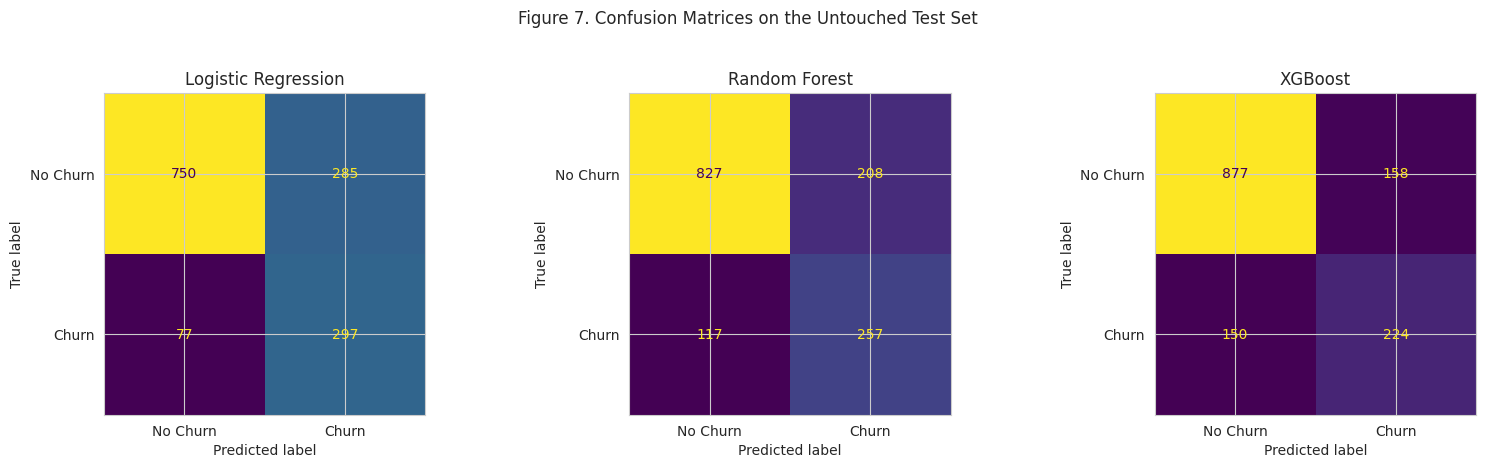

In [19]:
# Confusion matrices make the business trade-off visible, especially false negatives.
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (name, model) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        model_predictions[name]['pred'],
        display_labels=['No Churn', 'Churn'],
        colorbar=False,
        ax=ax
    )
    ax.set_title(name)
fig.suptitle('Figure 7. Confusion Matrices on the Untouched Test Set', y=1.03)
plt.tight_layout()
plt.show()

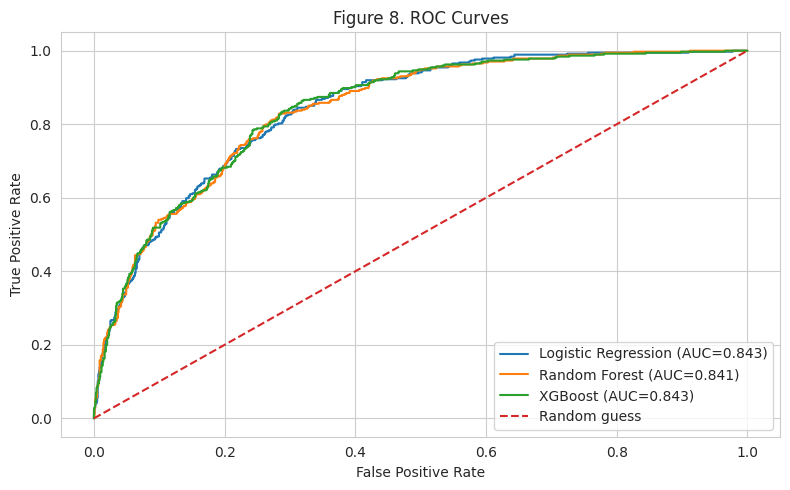

In [20]:
fig, ax = plt.subplots()
for name in models:
    fpr, tpr, _ = roc_curve(y_test, model_predictions[name]['proba'])
    auc = results_df.loc[name, 'AUC']
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
ax.plot([0, 1], [0, 1], linestyle='--', label='Random guess')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Figure 8. ROC Curves')
ax.legend()
plt.tight_layout()
plt.show()

## 11. Model Selection

`selected_model` is the model chosen for downstream scoring because it has the highest churn recall among the evaluated candidates. The printed precision, AUC, and F1 make the trade-off visible. This is a criterion-based selection, not a claim that one model is best for every objective. The later diagnostic sections assess a feature choice and probability reliability without changing this declared selection rule.


In [21]:
selected_model_name = results_df['Recall (Churn)'].idxmax()
selected_model = models[selected_model_name]

print(f'Selected model: {selected_model_name}')
print(f"Recall:    {results_df.loc[selected_model_name, 'Recall (Churn)']:.3f}")
print(f"Precision: {results_df.loc[selected_model_name, 'Precision (Churn)']:.3f}")
print(f"AUC:       {results_df.loc[selected_model_name, 'AUC']:.3f}")
print(f"F1:        {results_df.loc[selected_model_name, 'F1 (Churn)']:.3f}")

Selected model: Logistic Regression
Recall:    0.794
Precision: 0.510
AUC:       0.843
F1:        0.621


### 11.1 Probability calibration on the held-out test set

Discrimination asks whether churners tend to receive higher scores; calibration asks whether score magnitudes agree with observed frequencies. The curve below compares mean predicted probability with the fraction that actually churned in equal-frequency bins from the untouched test set. A curve near the diagonal is more consistent with calibrated probabilities. Bin counts matter, and a single split is only a diagnostic.

The Brier score is repeated here for the selected model as a compact probability-error measure. Since the model was trained after SMOTE changed the class balance, treat calibration carefully; if the curve shows systematic deviation, calibrate using training-only cross-validation or a separate calibration set before operational use. Do not fit calibration on this test set and then report the same test set as independent validation.


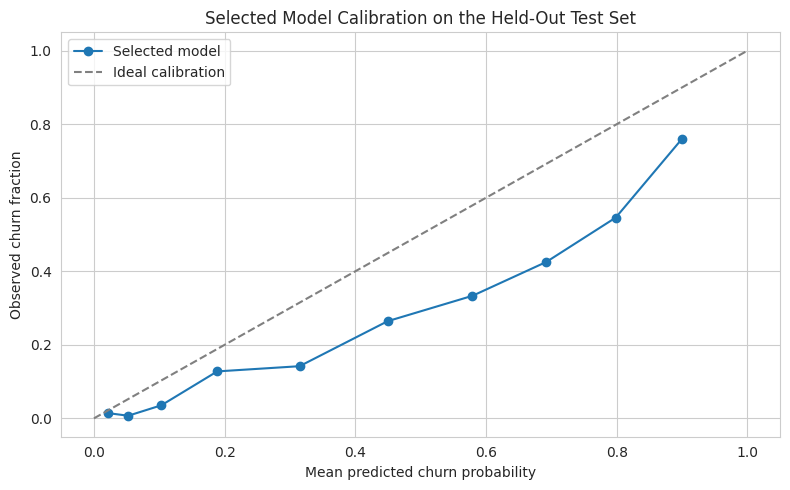

Selected model Brier score on test set: 0.166 (lower is better)
Interpret calibration as a diagnostic; bins can vary in size and this is one held-out split.


In [22]:
from sklearn.calibration import calibration_curve

calibration_fraction_positive, calibration_mean_predicted = calibration_curve(
    y_test,
    selected_model.predict_proba(X_test_processed)[:, 1],
    n_bins=10,
    strategy='quantile'
)
selected_test_probability = selected_model.predict_proba(X_test_processed)[:, 1]
selected_brier = brier_score_loss(y_test, selected_test_probability)

fig, ax = plt.subplots()
ax.plot(calibration_mean_predicted, calibration_fraction_positive, marker='o', label='Selected model')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Ideal calibration')
ax.set_xlabel('Mean predicted churn probability')
ax.set_ylabel('Observed churn fraction')
ax.set_title('Selected Model Calibration on the Held-Out Test Set')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Selected model Brier score on test set: {selected_brier:.3f} (lower is better)')
print('Interpret calibration as a diagnostic; bins can vary in size and this is one held-out split.')


### 11.2 Does `AvgMonthlySpend` help this model?

This controlled ablation compares the selected Logistic Regression workflow with and without `AvgMonthlySpend`, holding the train/test split, other predictors, and model family constant. The alternate preprocessor and SMOTE sampler are fitted only on training rows. The test set is used only to compare outcomes.

Review recall, precision, AUC, F1, and Brier score together. A small change on one split is not conclusive evidence that the feature helps; this comparison is a focused diagnostic, not a broad feature search. The selected production/scoring model above remains based on the previously stated recall criterion.


In [23]:
numeric_features_without_spend = [
    feature for feature in numeric_features if feature != 'AvgMonthlySpend'
]
preprocessor_without_spend = ColumnTransformer([
    ('num', StandardScaler(), numeric_features_without_spend),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

X_train_without_spend = preprocessor_without_spend.fit_transform(X_train)
X_test_without_spend = preprocessor_without_spend.transform(X_test)
smote_without_spend = SMOTE(random_state=RANDOM_STATE)
X_train_without_spend_resampled, y_train_without_spend_resampled = smote_without_spend.fit_resample(
    X_train_without_spend, y_train
)
log_reg_without_spend = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg_without_spend.fit(X_train_without_spend_resampled, y_train_without_spend_resampled)

ablation_rows = []
for feature_set, model, test_matrix in [
    ('With AvgMonthlySpend', log_reg, X_test_processed),
    ('Without AvgMonthlySpend', log_reg_without_spend, X_test_without_spend)
]:
    probability = model.predict_proba(test_matrix)[:, 1]
    prediction = (probability >= 0.50).astype(int)
    ablation_rows.append({
        'Feature Set': feature_set,
        'Recall (Churn)': recall_score(y_test, prediction, zero_division=0),
        'Precision (Churn)': precision_score(y_test, prediction, zero_division=0),
        'F1 (Churn)': f1_score(y_test, prediction, zero_division=0),
        'AUC': roc_auc_score(y_test, probability),
        'Brier Score': brier_score_loss(y_test, probability)
    })

feature_ablation_df = pd.DataFrame(ablation_rows).set_index('Feature Set')
display(feature_ablation_df.round(3))


,Recall (Churn),Precision (Churn),F1 (Churn),AUC,Brier Score
Feature Set,,,,,
With AvgMonthlySpend,0.794,0.510,0.621,0.843,0.166
Without AvgMonthlySpend,0.791,0.509,0.620,0.842,0.166


## 12. Threshold Analysis

The model produces a continuous score; a threshold converts that score into a Yes/No flag. The table reports test-set precision, recall, F1, number flagged, and share flagged at thresholds from 0.20 to 0.80. Lower thresholds usually flag more customers and capture more churners, at the cost of more false positives; higher thresholds usually reduce workload but miss more churners.

Figure 9 plots precision, recall, and F1 across these thresholds. Use the flagged count as a workload estimate and choose a threshold only after considering retention-team capacity and the costs of contacting customers unnecessarily versus missing a customer who leaves. This threshold sweep is descriptive decision support, not a validated policy.


In [24]:
selected_test_proba = selected_model.predict_proba(X_test_processed)[:, 1]
threshold_rows = []

for threshold in np.arange(0.20, 0.81, 0.05):
    pred_flag = (selected_test_proba >= threshold).astype(int)
    threshold_rows.append({
        'Threshold': round(float(threshold), 2),
        'Precision': precision_score(y_test, pred_flag, zero_division=0),
        'Recall': recall_score(y_test, pred_flag, zero_division=0),
        'F1': f1_score(y_test, pred_flag, zero_division=0),
        'FlaggedCustomers': int(pred_flag.sum()),
        'FlaggedRate': pred_flag.mean()
    })

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df.round(3))

,Threshold,Precision,Recall,F1,FlaggedCustomers,FlaggedRate
0,0.20,0.396,0.955,0.560,901,0.639
1,0.25,0.412,0.925,0.570,840,0.596
2,0.30,0.433,0.920,0.589,794,0.564
3,0.35,0.455,0.896,0.603,737,0.523
4,0.40,0.473,0.869,0.613,687,0.488
5,0.45,0.498,0.834,0.624,626,0.444
6,0.50,0.510,0.794,0.621,582,0.413
7,0.55,0.530,0.749,0.621,528,0.375
8,0.60,0.552,0.695,0.615,471,0.334
9,0.65,0.587,0.631,0.608,402,0.285


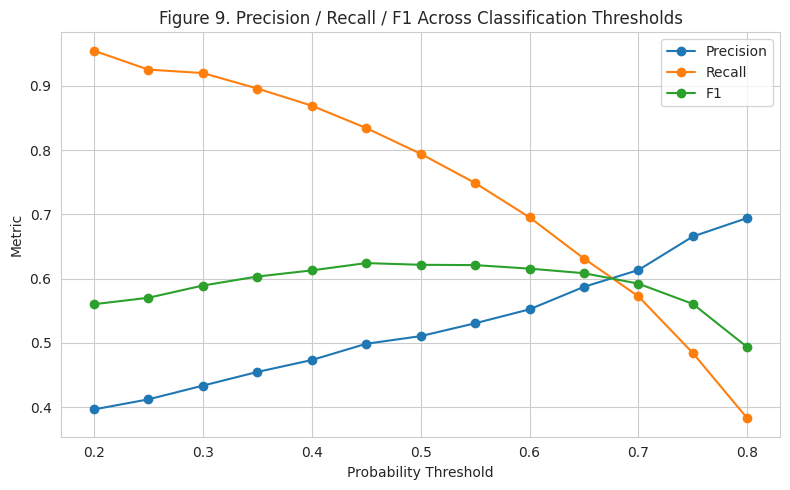

In [25]:
fig, ax = plt.subplots()
ax.plot(threshold_df['Threshold'], threshold_df['Precision'], marker='o', label='Precision')
ax.plot(threshold_df['Threshold'], threshold_df['Recall'], marker='o', label='Recall')
ax.plot(threshold_df['Threshold'], threshold_df['F1'], marker='o', label='F1')
ax.set_xlabel('Probability Threshold')
ax.set_ylabel('Metric')
ax.set_title('Figure 9. Precision / Recall / F1 Across Classification Thresholds')
ax.legend()
plt.tight_layout()
plt.show()

### Threshold interpretation

There is no universally optimal threshold in this notebook because no contact-capacity limit or explicit false-positive/false-negative cost was supplied. The selected model's continuous probability is retained in the export so decision-makers can examine other thresholds.

Threshold metrics above come from the held-out test set. Applying the selected threshold to every row in the historical file later is a scoring operation; it does not create a new independent performance estimate.


## 13. Probability Scoring & Operational Risk Tiers

The selected model scores all historical customer rows for segmentation and Power BI. The top-ten table is sorted by score and is a review of the highest-scored records; these are model outputs, not confirmed future churn events.

The fields have distinct meanings: `Churn` / `ChurnFlag` are historical outcomes; `ChurnProbability` is a model score; `PredictedChurnFlag50` and `PredictedChurnFlag60` apply explicit thresholds; and `RiskTier` uses the project's low/medium/high reporting bands. The 30% and 60% boundaries are operational labels, not validated intervention cut-offs. Because SMOTE changed the training class mix, probability calibration is checked separately on the untouched test set before interpreting these scores as reliable real-world probabilities.


In [26]:
X_full_processed = preprocessor.transform(X)

# Continuous model output — retain precision for analysis rather than rounding immediately.
df['ChurnProbability'] = selected_model.predict_proba(X_full_processed)[:, 1]

# Binary classification outputs at explicit thresholds.
df['PredictedChurnFlag50'] = (df['ChurnProbability'] >= 0.50).astype(int)
df['PredictedChurnFlag60'] = (df['ChurnProbability'] >= 0.60).astype(int)

# Operational risk tiers used in the original analysis.
df['RiskTier'] = pd.cut(
    df['ChurnProbability'],
    bins=[-np.inf, 0.30, 0.60, np.inf],
    labels=['Low', 'Medium', 'High'],
    right=False
)

display(
    df[['customerID', 'Contract', 'tenure', 'MonthlyCharges',
        'Churn', 'ChurnProbability', 'PredictedChurnFlag50', 'RiskTier']]
    .sort_values('ChurnProbability', ascending=False)
    .head(10)
)

,customerID,Contract,tenure,MonthlyCharges,Churn,ChurnProbability,PredictedChurnFlag50,RiskTier
1976,9497-QCMMS,Month-to-month,1,93.55,Yes,0.964416,1,High
4800,9300-AGZNL,Month-to-month,1,94.00,Yes,0.964018,1,High
1410,7024-OHCCK,Month-to-month,2,93.85,Yes,0.963984,1,High
6368,2720-WGKHP,Month-to-month,2,94.00,Yes,0.963402,1,High
3380,5178-LMXOP,Month-to-month,1,95.10,Yes,0.963324,1,High
3749,4424-TKOPW,Month-to-month,2,93.85,Yes,0.963138,1,High
3209,8149-RSOUN,Month-to-month,1,93.85,Yes,0.962534,1,High
5989,5567-WSELE,Month-to-month,3,94.60,Yes,0.962265,1,High
2577,4910-GMJOT,Month-to-month,1,94.60,Yes,0.961833,1,High
2208,7216-EWTRS,Month-to-month,1,100.80,Yes,0.961127,1,High


,RiskTier,Customers,ActualChurnRate,AvgPredictedProbability,MonthlyCharges
0,Low,3108,0.0505,0.1082,172096.0
1,Medium,1637,0.2376,0.4528,105402.0
2,High,2298,0.5757,0.7795,178618.6


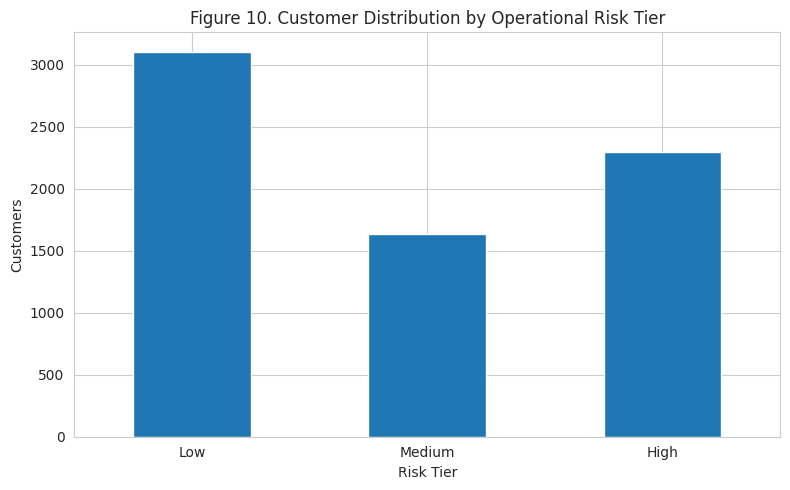

In [27]:
risk_summary = (
    df.groupby('RiskTier', observed=True)
      .agg(
          Customers=('customerID', 'count'),
          ActualChurnRate=('ChurnFlag', 'mean'),
          AvgPredictedProbability=('ChurnProbability', 'mean'),
          MonthlyCharges=('MonthlyCharges', 'sum')
      )
      .reset_index()
)

risk_summary['ActualChurnRate'] = risk_summary['ActualChurnRate'].round(4)
risk_summary['AvgPredictedProbability'] = risk_summary['AvgPredictedProbability'].round(4)
risk_summary['MonthlyCharges'] = risk_summary['MonthlyCharges'].round(2)

display(risk_summary)

fig, ax = plt.subplots()
risk_counts = df['RiskTier'].value_counts().reindex(['Low', 'Medium', 'High'])
risk_counts.plot(kind='bar', ax=ax)
ax.set_title('Figure 10. Customer Distribution by Operational Risk Tier')
ax.set_xlabel('Risk Tier')
ax.set_ylabel('Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 14. Power BI Data Layer

This section creates the row-level scored table and summary tables for the dashboard. `ActualChurnRate`, `AverageChurnProbability`, `PredictedChurnRate50`, `PredictedChurnRate60`, and `HighRiskRate` answer different questions and should be labelled distinctly in report cards.

The `Segment_Summary` output groups contract and internet service together and includes customer counts, actual churn rate, mean model score, and high-risk share. Read its rates beside the group size. The reconciliation sheet helps compare imported Power BI totals against notebook totals. Full-customer scoring includes training rows, so use the held-out evaluation tables for model-performance claims.


In [28]:
scored_export = df[[
    'customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
    'tenure', 'TenureGroup', 'Contract', 'InternetService', 'PaymentMethod',
    'PaperlessBilling', 'NumAddonServices', 'MonthlyCharges', 'TotalCharges',
    'AvgMonthlySpend', 'Churn', 'ChurnFlag', 'ChurnProbability',
    'PredictedChurnFlag50', 'PredictedChurnFlag60', 'RiskTier'
]].copy()

kpi_summary = pd.DataFrame([{
    'TotalCustomers': len(df),
    'ChurnedCustomers': int(df['ChurnFlag'].sum()),
    'ActualChurnRate': df['ChurnFlag'].mean(),
    'AverageChurnProbability': df['ChurnProbability'].mean(),
    'PredictedChurnRate50': df['PredictedChurnFlag50'].mean(),
    'PredictedChurnRate60': df['PredictedChurnFlag60'].mean(),
    'HighRiskCustomers': int((df['RiskTier'] == 'High').sum()),
    'HighRiskRate': (df['RiskTier'] == 'High').mean(),
    'HighRiskMonthlyRevenueAtStake': df.loc[df['RiskTier'] == 'High', 'MonthlyCharges'].sum(),
    'AverageMonthlyCharges': df['MonthlyCharges'].mean(),
    'AverageTenureMonths': df['tenure'].mean()
}])

segment_summary = (
    df.groupby(['Contract', 'InternetService'], observed=True)
      .agg(
          Customers=('customerID', 'count'),
          ActualChurnRate=('ChurnFlag', 'mean'),
          AverageChurnProbability=('ChurnProbability', 'mean'),
          HighRiskRate=('PredictedChurnFlag60', 'mean'),
          AvgMonthlyCharges=('MonthlyCharges', 'mean')
      )
      .reset_index()
)

segment_summary['ActualChurnRate'] = segment_summary['ActualChurnRate'].round(4)
segment_summary['AverageChurnProbability'] = segment_summary['AverageChurnProbability'].round(4)
segment_summary['HighRiskRate'] = segment_summary['HighRiskRate'].round(4)
segment_summary['AvgMonthlyCharges'] = segment_summary['AvgMonthlyCharges'].round(2)

reconciliation_log = pd.DataFrame([
    {'Check': 'Raw rows loaded', 'Value': len(df), 'Notes': 'Should equal source dataset rows'},
    {'Check': 'Duplicate customerID rows', 'Value': int(df['customerID'].duplicated().sum()), 'Notes': 'Expected 0'},
    {'Check': 'Duplicate full rows', 'Value': int(df.duplicated().sum()), 'Notes': 'Expected 0'},
    {'Check': 'Rows exported', 'Value': len(scored_export), 'Notes': 'No customers intentionally dropped'},
    {'Check': 'Null ChurnProbability', 'Value': int(scored_export['ChurnProbability'].isna().sum()), 'Notes': 'Expected 0'},
    {'Check': 'Null RiskTier', 'Value': int(scored_export['RiskTier'].isna().sum()), 'Notes': 'Expected 0'},
    {'Check': 'Actual churn rate', 'Value': float(df['ChurnFlag'].mean()), 'Notes': 'Historical observed rate'},
    {'Check': 'Average predicted probability', 'Value': float(df['ChurnProbability'].mean()), 'Notes': 'Model output; not actual churn rate'}
])

with pd.ExcelWriter(OUTPUT_PATH, engine='openpyxl') as writer:
    scored_export.to_excel(writer, sheet_name='Scored_Customers', index=False)
    kpi_summary.to_excel(writer, sheet_name='KPI_Summary', index=False)
    segment_summary.to_excel(writer, sheet_name='Segment_Summary', index=False)
    results_df.to_excel(writer, sheet_name='Model_Comparison')
    threshold_df.to_excel(writer, sheet_name='Threshold_Analysis', index=False)
    risk_summary.to_excel(writer, sheet_name='Risk_Summary', index=False)
    reconciliation_log.to_excel(writer, sheet_name='Reconciliation_Log', index=False)

print(f'Exported {OUTPUT_PATH}')
print('Sheets: Scored_Customers, KPI_Summary, Segment_Summary, Model_Comparison, Threshold_Analysis, Risk_Summary, Reconciliation_Log')

Exported churn_scored_data_v2.xlsx
Sheets: Scored_Customers, KPI_Summary, Segment_Summary, Model_Comparison, Threshold_Analysis, Risk_Summary, Reconciliation_Log


## 15. Conclusion, Recommendations & Limitations

### Conclusion

This analysis links a historical churn baseline to customer-segment patterns, held-out model evaluation, threshold trade-offs, and a Power BI scoring layer. The central reporting rule is to keep four ideas separate: historical churn, individual model scores, threshold-based flags, and operational risk bands. The headline model is selected for its stated recall objective; the calibration and feature-ablation outputs provide additional evidence to consider before using probabilities or engineered features operationally.

Use the contract-by-service and tenure findings to decide which customer groups merit closer business investigation. Use customer scores to prioritise review or design a controlled retention experiment, not as a promise that an individual will churn. A future intervention should be measured against an appropriate comparison group so its impact can be estimated.

### Recommended next steps

1. Confirm the interpretation with current company data and stakeholders who know retention capacity and intervention costs.
2. Review the test-set calibration curve; if probabilities are materially miscalibrated, calibrate using training-only cross-validation or a separate calibration set, then validate on data not used to fit the calibrator.
3. Choose a contact threshold only after specifying capacity and the relative cost of false positives and false negatives.
4. Compare the `AvgMonthlySpend` ablation across repeated or cross-validated splits before deciding whether it belongs in the final feature set.
5. Replace standard SMOTE after one-hot encoding with a categorical-aware approach and validate on a later time period if deployment is contemplated.
6. In Power BI, label actual churn rate, average predicted probability, predicted churn rate at 50%/60%, and high-risk rate explicitly; show segment counts beside rates.

### Limitations

- The dataset is historical and may not represent today's customers, products, or retention process.
- EDA rates show association, not causation. Segment sizes and sampling variation matter.
- A single stratified holdout gives one estimate of model performance; repeated validation or temporal validation would provide stronger evidence.
- SMOTE is applied to one-hot encoded features, which can generate fractional category indicators.
- Training on a resampled class distribution can affect probability calibration. Brier score and the calibration curve are diagnostics, not a guarantee of reliable future probabilities.
- Threshold performance depends on the chosen model, split, costs, and customer-contact capacity.
- Full-customer scores include customers used in model training and are intended for historical segmentation and dashboard demonstration, not independent performance reporting.
- The 30% and 60% risk-tier boundaries are reporting choices, not validated business-optimal actions.
- `AvgMonthlySpend` is derived from fields already in the data and may be redundant; use the ablation output as preliminary evidence.

### Final takeaway

The notebook supports a clear descriptive and predictive workflow. Its strongest practical value is showing where observed churn differs, how model recall trades off against precision and workload, and how to carry distinct measures into Power BI. Any operational use should follow calibration checks, business threshold selection, and prospective validation.
